# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

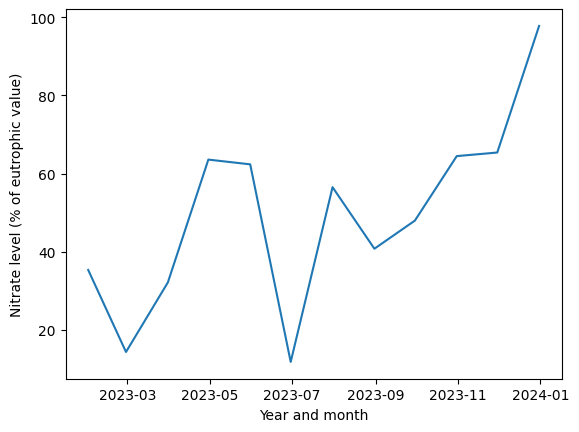

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

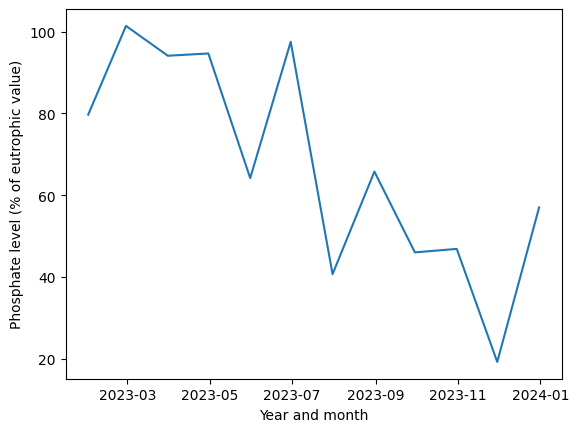

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

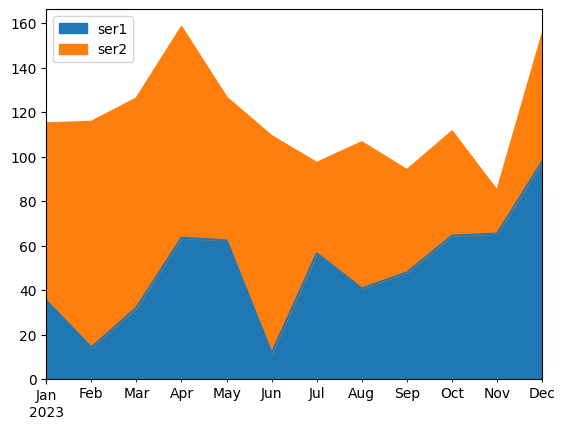

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

When looking at the area chart compared to the two line graphs, one advantage is you can see the two trends on the same chart. This allows us to see if there is any similar trends between the two. For example, we can see for both elements, they had a spike in April. However, a big disadvantage is that the y-axis isn't as understandable as it is in the two line charts. This is partially due to the lack of a y-axis label explaining what the numbers are representing. It is also important to note that the phosphate levels don't follow the same pattern as the line chart for the phosphate due to the stacked aspect of the chart. I would opt for the two line charts as we can compare them side by side and see if there is any noticeable correlations. I would also be sure to add x and y labels as well as a title to ensure the audience understands what the charts are representing.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Dataset 1: Instacart Data

For this dataset, I intially had to create a whole new model dataframe out of multiple csv files I was provided off of Kaggle. To do this, I had to use Google Colab as GitHub's file size limit was smaller than the size of one of the CSV files. To do this, I joined together files into the prior dataset and then created model features. Once I created the features, I joined them with the training dataset with a left join and filled NA values with 0. I then exported this model dataset and imported it into GitHub so I am able to perform my analysis here. 

In [6]:
import matplotlib.pyplot as plt

In [7]:
model_data = pd.read_csv('/workspaces/DX699---HW-Assignments/instacart.csv')

model_data.head()

,user_id,product_id,times_purchased,num_orders,frequency,Product Popularity,Last Product Order,Last Order,Orders Since Last Purchase,ordered
0,71,45,5,23,0.217391,0.005895,9,23,14,0.0
1,71,117,19,23,0.826087,0.001220,23,23,0,1.0
2,71,2078,1,23,0.043478,0.006499,3,23,20,0.0
3,71,2825,2,23,0.086957,0.003750,6,23,17,0.0
4,71,3376,2,23,0.086957,0.003609,19,23,4,1.0


<Axes: >

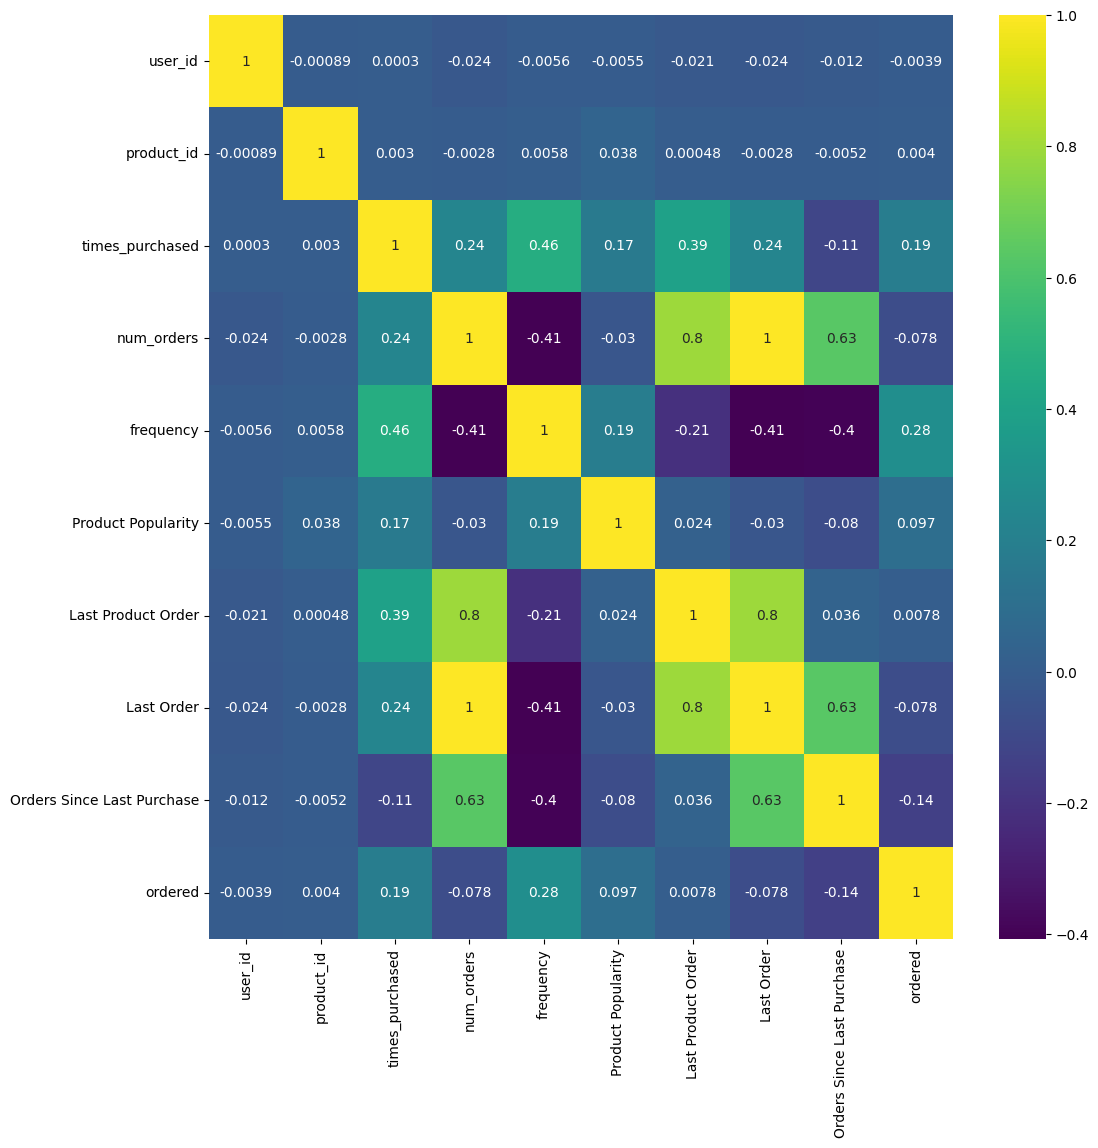

In [8]:
plt.figure(figsize = (12, 12))
sns.heatmap(model_data.corr(), annot = True, cmap = 'viridis')

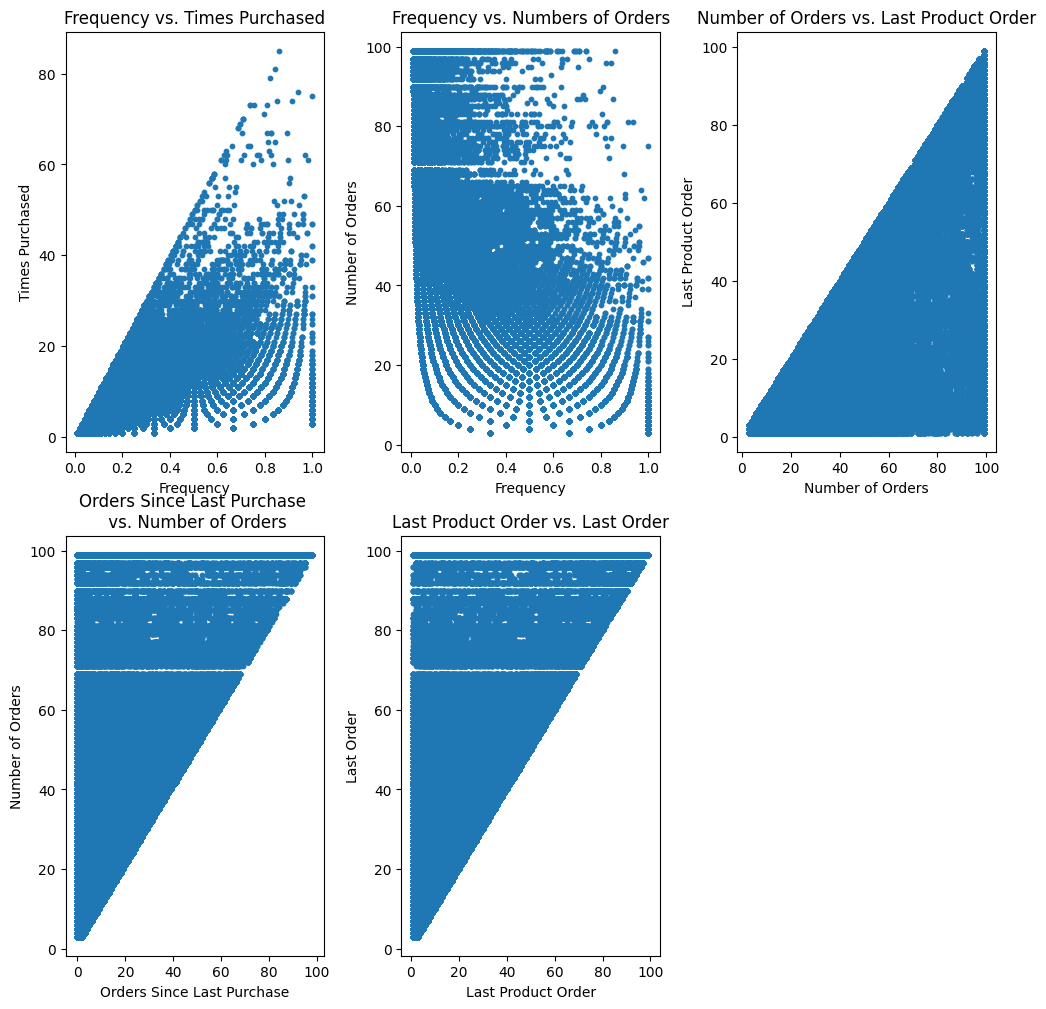

In [9]:
plt.figure(figsize = (12, 12))

plt.subplot(2, 3, 1)
plt.scatter(model_data['frequency'], model_data['times_purchased'], s = 10)
plt.xlabel('Frequency')
plt.ylabel('Times Purchased')
plt.title('Frequency vs. Times Purchased')

plt.subplot(2, 3, 2)
plt.scatter(model_data['frequency'], model_data['num_orders'], s = 10)
plt.xlabel('Frequency')
plt.ylabel('Number of Orders')
plt.title('Frequency vs. Numbers of Orders')

plt.subplot(2, 3, 3)
plt.scatter(model_data['num_orders'], model_data['Last Product Order'], s = 10)
plt.xlabel('Number of Orders')
plt.ylabel('Last Product Order')
plt.title('Number of Orders vs. Last Product Order')

plt.subplot(2, 3, 4)
plt.scatter(model_data['Orders Since Last Purchase'], model_data['num_orders'], s = 10)
plt.xlabel('Orders Since Last Purchase')
plt.ylabel('Number of Orders')
plt.title('Orders Since Last Purchase \n vs. Number of Orders')

plt.subplot(2, 3, 5)
plt.scatter(model_data['Last Product Order'], model_data['Last Order'], s = 10)
plt.xlabel('Last Product Order')
plt.ylabel('Last Order')
plt.title('Last Product Order vs. Last Order')

plt.subplots_adjust(wspace = 0.3)
plt.show()

I plotted the correlation matrix and then plotted the five highest correlations between variables. I am not surprised by a lot of these correlations since they are similar features, like last product order and last order. I also would expect the orders since last purchase to have a positive correlation with number of orders. 

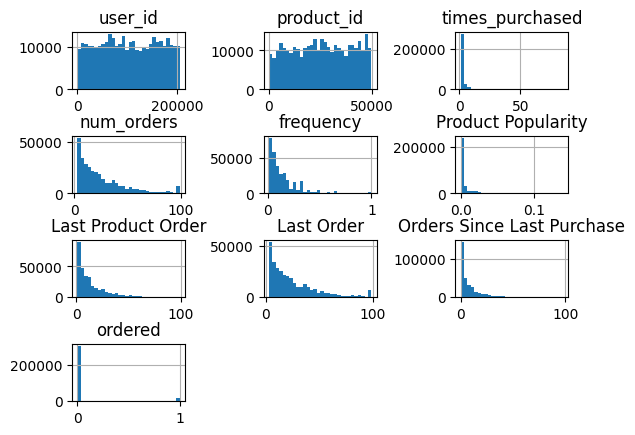

In [10]:
model_data.hist(bins = 30)
plt.subplots_adjust(wspace = 0.7, hspace = 0.8)
plt.show()

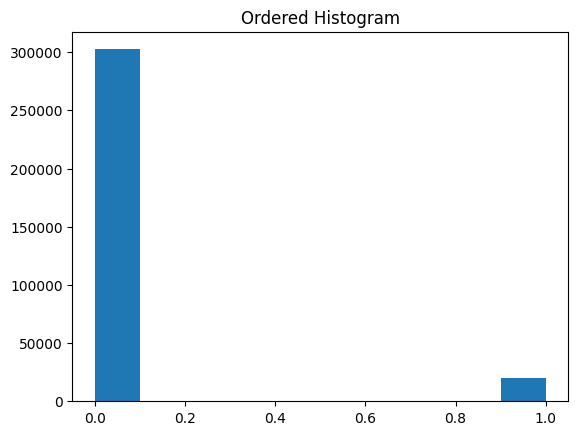

In [11]:
model_data['ordered'].hist(grid = False)
plt.title('Ordered Histogram')
plt.show()

Text(0.5, 1.0, 'Last Order Box Plot')

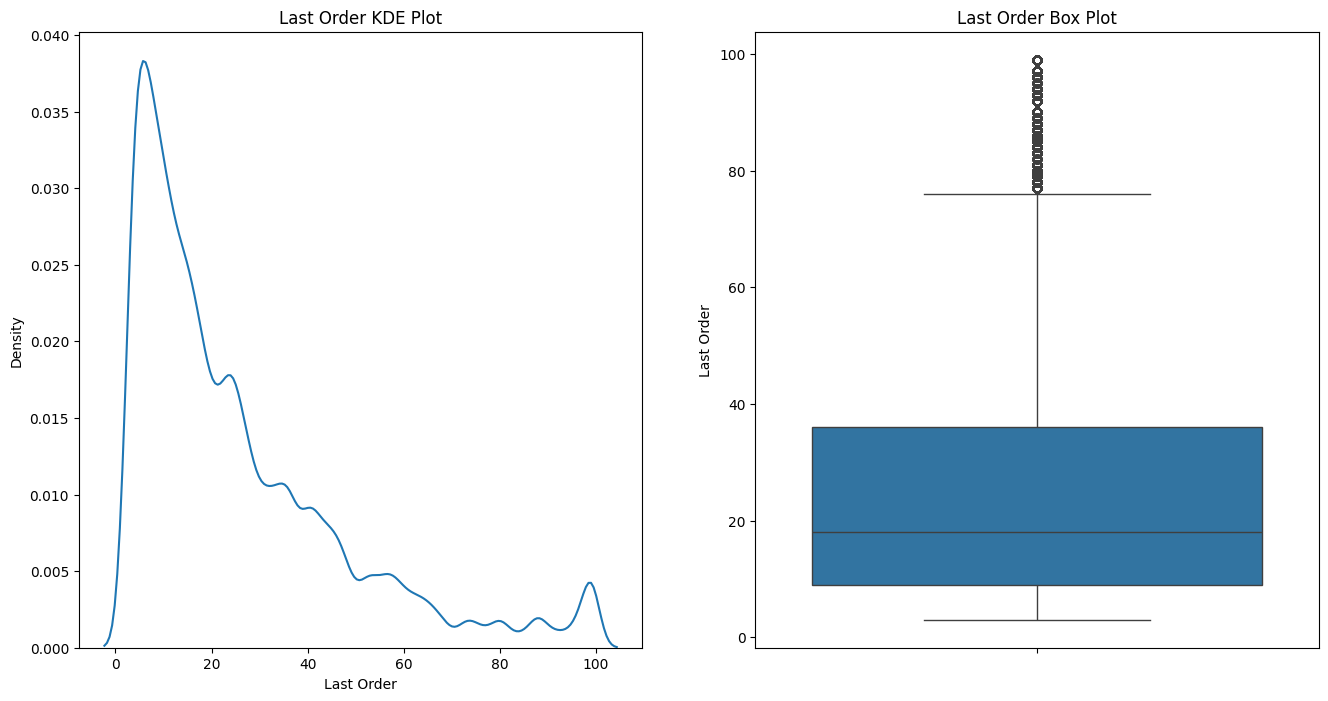

In [12]:
plt.figure(figsize = (16, 8))

plt.subplot(1, 2, 1)
sns.kdeplot(model_data['Last Order'])
plt.title('Last Order KDE Plot')

plt.subplot(1, 2, 2)
sns.boxplot(model_data['Last Order'])
plt.title('Last Order Box Plot')

I wanted to look closer at the shape of the last order column since it has the smaller spike at the end in the 100 range. The last order represents the number of their last order, or how many total orders the user has purchased. Looking at this chart it can be seen that for most users they have only place around 10 orders and then there is a steep decrease after the peak. However, there is a smaller peak at the end near the 100 which means that there are some users that have placed much more orders. I am curious if these users' orders will end up having a bias on the model since they have more order history data than others.

In [13]:
info = pd.DataFrame({'Mean' : model_data.mean(), 'Median' : model_data.median(), 'Mode' : model_data.mode().iloc[0]})

info

,Mean,Median,Mode
user_id,103432.155558,101943.000000,75304.000000
product_id,25524.143860,25640.000000,24852.000000
times_purchased,2.415384,1.000000,1.000000
num_orders,25.494503,18.000000,3.000000
frequency,0.153110,0.093750,0.333333
Product Popularity,0.007004,0.001374,0.000013
Last Product Order,15.879273,10.000000,3.000000
Last Order,25.494503,18.000000,3.000000
Orders Since Last Purchase,9.615230,4.000000,0.000000
ordered,0.062002,0.000000,0.000000


In [14]:
transform_cols = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase']

for col in transform_cols:
    model_data[f'log_{col}'] = np.log1p(model_data[col])

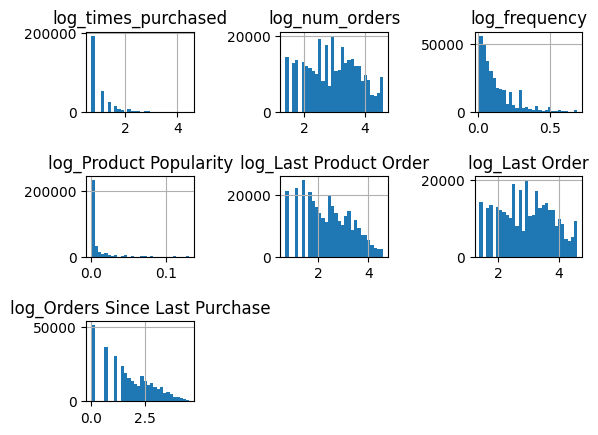

In [15]:
model_data[['log_times_purchased', 'log_num_orders', 'log_frequency', 'log_Product Popularity', 'log_Last Product Order', 'log_Last Order', 'log_Orders Since Last Purchase']].hist(bins = 30)

plt.subplots_adjust(wspace = 0.8, hspace = 0.8)
plt.show()

In [16]:
model_data_transformed = model_data.drop(columns = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase'])

In [17]:
model_data_transformed['ordered'].value_counts()

ordered
0.0    302447
1.0     19992
Name: count, dtype: int64

In [18]:
model_data_transformed.groupby('user_id').size()

user_id
71        106
102        34
106        36
124        48
129        33
         ... 
206054     51
206084     55
206126    193
206138     29
206165    318
Length: 5000, dtype: int64

Looking at the histogram distributions I know that I will need to log transform all of the values as they are all heavily skewed to the left. This will help balance out the values and reduce the bias. Once I conducted the transformation, I plotted the histograms and could see an improvement in the skewness for most of the variables. Times purchased is the only one that didn't change much, but it still had a transformation and has more values instead of one small subset of values. Furthermore, I notice that there are far more 0s for ordered instead of 1s in the reordered column. This class imbalance may lead to the model having some bias towards 0s when predicting, however, the class imbalance being large isn't too surprising. This is because often the user who is ordering has ordered over 50 items in there past and they aren't always going to order all of the items again. This would lead to there being more 0s, especially for users who have ordered over 100s of items in their past.

Looking at the table of Mean, Median and Mode, I can see that a lot of products are not that popular since the product popularity values are all very low percentages. Furthermore, looking at the Mode column for frequency, it is most common for a product to have a 33% frequency of being ordered. This was calculated by dividing the number of times the product was ordered by a user and the number of times a user has ordered.

There also should be no NA values in this dataset as I filled all the NA values with 0 when I joined the tables together. Furthermore, I will be checking the rows for duplicates quickly below. I am assuming there will be no duplicates as each row relates to a product a user purchased in a past order and whether they will reorder it.

In [19]:
dups = model_data_transformed.duplicated()

np.unique(dups)

array([False])

## Dataset 2: Amazon Reviews of Grocery and Food Items

This next dataset had the same issue as the instacart one of it being too large to upload to Github right away. To deal with this, I uploaded it into Google Colab and created a smaller subset to work with on Github.

In [20]:
small_reviews = pd.read_csv('/workspaces/DX699---HW-Assignments/small_reviews[1].csv')
small_reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and...,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395,0,True
1,5,Delicious!!! Yum!,Excellent! The best! I use it with my beef a...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380,0,True
2,5,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft ...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527,1,True
3,5,Delicious!,My favorite!,[],B07194LN2Z,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614,0,True
4,5,Great taste,Great for making brownies and crinkle cookies.,[],B005CD4196,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965,7,True


In [21]:
small_meta = pd.read_csv('/workspaces/DX699---HW-Assignments/small_meta[1].csv')
small_meta.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Grocery,Dark Roast Pure Coffee,4.7,9,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'YouCut_20220Cafe Du Monde Coffee C...,Luzianne,"['Grocery & Gourmet Food', 'Beverages', 'Coffee']","{'Brand': 'Luzianne', 'Item Form': 'Ground', '...",B00NE08WM6,NaN,NaN,NaN
1,Grocery,PICARAS Galletas Peruanas Bañadas en Chocolate...,4.5,12,['2 Bags of PICARAS Galletas Bañadas en Chocol...,['2 Bags of PICARAS Galletas Bañadas en Chocol...,15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Winters,"['Grocery & Gourmet Food', 'Breads & Bakery', ...","{'Flavor': 'chocolate', 'Unit Count': '12.00 C...",B084Q13Q5Q,NaN,NaN,NaN
2,Grocery,Chipped Beef and Gravy By Patterson's - Great ...,3.2,5,['Six (6) 8-ounce cans of delicious chipped be...,"[""Delicious corned beef gravy is ready when yo...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pattersons,"['Grocery & Gourmet Food', 'Pantry Staples', '...",{'Package Dimensions': '8.4 x 5.8 x 3.4 inches...,B00KBRUYVM,NaN,NaN,NaN
3,Grocery,Asher's Sugar Free Milk Chocolate Cordial Cher...,5.0,6,[],[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'No Sugar Added Chocolate Truffles'...,Generic,"['Grocery & Gourmet Food', 'Snacks & Sweets', ...","{'Brand': 'Generic', 'Item Form': 'Ball', 'Cho...",B0BN4PW255,NaN,NaN,NaN
4,Grocery,Messmer Peppermint 25 bags (6er pack),3.5,5,[],[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Messmer,[],"{'Brand': 'Messmer', 'Item Form': 'Teabags', '...",B06X9DC27H,NaN,NaN,NaN


In [22]:
small_meta = small_meta.set_index(keys = 'parent_asin')

small_meta = small_meta.drop(columns = ['title', 'images'])

small_meta

,main_category,average_rating,rating_number,features,description,price,videos,store,categories,details,bought_together,subtitle,author
parent_asin,,,,,,,,,,,,,
B00NE08WM6,Grocery,4.7,9,[],[],NaN,[{'title': 'YouCut_20220Cafe Du Monde Coffee C...,Luzianne,"['Grocery & Gourmet Food', 'Beverages', 'Coffee']","{'Brand': 'Luzianne', 'Item Form': 'Ground', '...",NaN,NaN,NaN
B084Q13Q5Q,Grocery,4.5,12,['2 Bags of PICARAS Galletas Bañadas en Chocol...,['2 Bags of PICARAS Galletas Bañadas en Chocol...,15.99,[],Winters,"['Grocery & Gourmet Food', 'Breads & Bakery', ...","{'Flavor': 'chocolate', 'Unit Count': '12.00 C...",NaN,NaN,NaN
B00KBRUYVM,Grocery,3.2,5,['Six (6) 8-ounce cans of delicious chipped be...,"[""Delicious corned beef gravy is ready when yo...",NaN,[],Pattersons,"['Grocery & Gourmet Food', 'Pantry Staples', '...",{'Package Dimensions': '8.4 x 5.8 x 3.4 inches...,NaN,NaN,NaN
B0BN4PW255,Grocery,5.0,6,[],[],29.99,[{'title': 'No Sugar Added Chocolate Truffles'...,Generic,"['Grocery & Gourmet Food', 'Snacks & Sweets', ...","{'Brand': 'Generic', 'Item Form': 'Ball', 'Cho...",NaN,NaN,NaN
B06X9DC27H,Grocery,3.5,5,[],[],29.99,[],Messmer,[],"{'Brand': 'Messmer', 'Item Form': 'Teabags', '...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
B07CR88C9F,Grocery,4.6,1107,['An assortment just for cacao-lovers. Featuri...,[],37.70,[],See's Candies,"['Grocery & Gourmet Food', 'Snacks & Sweets', ...","{'Brand': ""See's Candies"", 'Item Form': 'Bar',...",NaN,NaN,NaN
B000HBO14I,Grocery,3.8,27,['Honey and lemon taste delicious together and...,"['Product Description', 'Want the delicate, cl...",NaN,[],Lipton,"['Grocery & Gourmet Food', 'Beverages', 'Bottl...","{'Is Discontinued By Manufacturer': 'Yes', 'Pa...",NaN,NaN,NaN
B08R6D2RBB,Grocery,4.0,61,"['KOREAN BBQ: Flavor of Tamari, Honey and Garl...","[""King's Beef Korean BBQ Beef Jerky is filled ...",NaN,[],Kings Beef,"['Grocery & Gourmet Food', 'Snacks & Sweets', ...","{'Brand': 'Kings Beef', 'Flavor': 'Korean BBQ'...",NaN,NaN,NaN


In [23]:
amazon_data = small_reviews.join(small_meta, on = 'parent_asin', how = 'inner')

In [24]:
amazon_data.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,...,features,description,price,videos,store,categories,details,bought_together,subtitle,author
10,5,Yummy tea!,Luckily I purchased this on a lightning deal f...,[],B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-01-23 01:51:58.951,0,False,...,['HIMALAYAS\u200b GOLDEN\u200b GIFT TO THE WOR...,[],24.99,"[{'title': ""Taste Test: Vahdam India's Origina...",VAHDAM,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...","{'Brand': 'VAHDAM', 'Item Form': 'Loose Leaf',...",NaN,NaN,NaN
22,1,Overpriced With No Noticeable Difference,I have tried four other reishi products on the...,[],B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2015-12-18 16:30:52.000,26,True,...,['BE WELL — Mushroom Elixir with Chaga contain...,['Drink to your daily well-being with our Chag...,27.54,"[{'title': ""Lion's Mane Elixir Review"", 'url':...",Four Sigmatic,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...","{'Item Form': 'Powder', 'Brand': 'Four Sigmati...",NaN,NaN,NaN
38,4,Four Stars,Love it but it could be a little more robust. ...,[],B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2018-02-22 16:33:14.462,0,True,...,['Pure Tanzania AA Coffee from the Nglia Estat...,[],NaN,[{'title': 'Volcanica Coffee - Specialty Coffe...,Volcanica Coffee,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...","{'Is Discontinued By Manufacturer': 'No', 'Pro...",NaN,NaN,NaN
40,5,More Please!,The best tasting Nutritional Yeast on the plan...,[],B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2017-09-09 23:16:57.759,0,True,...,['FLAVOR-PACKED NUTRITIONAL YEAST: Our Nutriti...,[],14.99,"[{'title': ""You'll love this Nutritional Yeast...",Sari Foods Co,"['Grocery & Gourmet Food', 'Pantry Staples', '...","{'Brand': 'Sari Foods Co', 'Item Form': 'Powde...",NaN,NaN,NaN
83,5,Great flavors,Reasonable price and great quality!,[],B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,2023-01-07 18:25:12.338,0,True,...,"['100 Donut Style Blend coffee pods', 'Blend o...",['Solimo Donut Style Blend coffee k-cup pods a...,28.82,[{'title': 'What you need to know about Solimo...,Solimo,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",{'Product Dimensions': '11.75 x 9.87 x 7.25 in...,NaN,NaN,NaN


In [25]:
amazon_data.info()

<class 'pandas.DataFrame'>
Index: 583 entries, 10 to 9949
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             583 non-null    int64  
 1   title              583 non-null    str    
 2   text               583 non-null    str    
 3   images             583 non-null    str    
 4   asin               583 non-null    str    
 5   parent_asin        583 non-null    str    
 6   user_id            583 non-null    str    
 7   timestamp          583 non-null    str    
 8   helpful_vote       583 non-null    int64  
 9   verified_purchase  583 non-null    bool   
 10  main_category      583 non-null    str    
 11  average_rating     583 non-null    float64
 12  rating_number      583 non-null    int64  
 13  features           583 non-null    str    
 14  description        583 non-null    str    
 15  price              413 non-null    float64
 16  videos             583 non-null    str  

This dataset has a lot of columns that are not useful to me right now as they are either filled with a lot of null values, do not have a use in a recommender like images and videos since we can't see them, and contain long text features. In the future, I may begin sentiment analysis with the text column to add a column of positive and negative, but I would like to first build a recommender system using features I am confident with and then will begin advanced techniques after.

In [26]:
amazon_data = amazon_data.drop(columns = ['main_category', 'store', 'rating_number', 'videos', 'images', 'subtitle', 'author', 'bought_together', 'features', 'description', 'details', 'timestamp', 'text', 'title'])

amazon_data.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,categories
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,"['Grocery & Gourmet Food', 'Beverages', 'Tea',..."
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,"['Grocery & Gourmet Food', 'Beverages', 'Tea',..."
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,NaN,"['Grocery & Gourmet Food', 'Beverages', 'Coffe..."
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,"['Grocery & Gourmet Food', 'Pantry Staples', '..."
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,"['Grocery & Gourmet Food', 'Beverages', 'Coffe..."


After dropping those columns, I am going to add two more features I created for the recommender system. These are the number of reviews per product and the total number of reviews a user has written. I was struggling adding the product review counts and user review counts to my dataframe so I proceeded to google how to add a groupby calculation into a new dataframe column in python and found this website explaining the transform function to complete this. This is the link: https://stackoverflow.com/questions/30244952/how-do-i-create-a-new-column-from-the-output-of-pandas-groupby-sum

In [27]:
amazon_data['product_review_count'] = amazon_data.groupby('asin').transform('size')
amazon_data['user_review_count'] = amazon_data.groupby('user_id').transform('size')

amazon_data.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,categories,product_review_count,user_review_count
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...",1,1
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...",1,1
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,NaN,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",1,2
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,"['Grocery & Gourmet Food', 'Pantry Staples', '...",1,2
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",4,1


Next, I have to fill the null values in the price column as 170 of the rows are null values. To do this I am filling them with the median value since a lot of the rows are null and I don't want to lose that much data.

In [28]:
amazon_data['price'].isna().sum()

np.int64(170)

In [29]:
amazon_data['price'] = amazon_data['price'].fillna(amazon_data['price'].median())

amazon_data['price'].isna().sum()

np.int64(0)

My next step is breaking down the categories column into encoded category columns. This is because the categories column right now contains nested lists. I was unsure on how to proceed with this so I asked ChatGPT for help. I have attached the link to the chat here: https://chatgpt.com/share/69b1877c-82e8-800c-897e-a0f0be56cc84

In [30]:
import ast

amazon_data['categories'] = amazon_data['categories'].apply(ast.literal_eval)

amazon_data['categories'].head()

10      [Grocery & Gourmet Food, Beverages, Tea, Black]
22    [Grocery & Gourmet Food, Beverages, Tea, Fruit...
38    [Grocery & Gourmet Food, Beverages, Coffee, Wh...
40    [Grocery & Gourmet Food, Pantry Staples, Cooki...
83    [Grocery & Gourmet Food, Beverages, Coffee, Si...
Name: categories, dtype: object

In [31]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

categories = pd.DataFrame(mlb.fit_transform(amazon_data['categories']), columns = mlb.classes_, index = amazon_data.index)

categories

,Active Dry Yeasts,Almond Butter,Almonds,Apple Cider,Assortments & Samplers,Bakery & Dessert Gifts,"Baking Chocolates, Carob & Cocoa",Baking Mixes,"Baking Syrups, Sugars & Sweeteners",Barbecue,...,Vegetables,Vinegars,Wafers,Walnuts,Water,Water Flavoring Drops,Wheat,White,Whole Coffee Beans,Yellow Mustard
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
40,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9935,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9941,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
top_30 = categories.sum().sort_values(ascending = False).head(31).index

categories = categories[top_30[1:31]]

categories

,Beverages,Snacks & Sweets,Pantry Staples,Coffee,Snack Foods,Candy & Chocolate,"Bottled Beverages, Water & Drink Mixes",Cooking & Baking,Breads & Bakery,Single-Serve Capsules & Pods,...,Granola,Fruit & Herbal Tea,Herbal,Bars,Roasted Coffee Beans,Whole Coffee Beans,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black
10,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
22,1,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
38,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
40,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
83,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9903,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9935,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9941,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


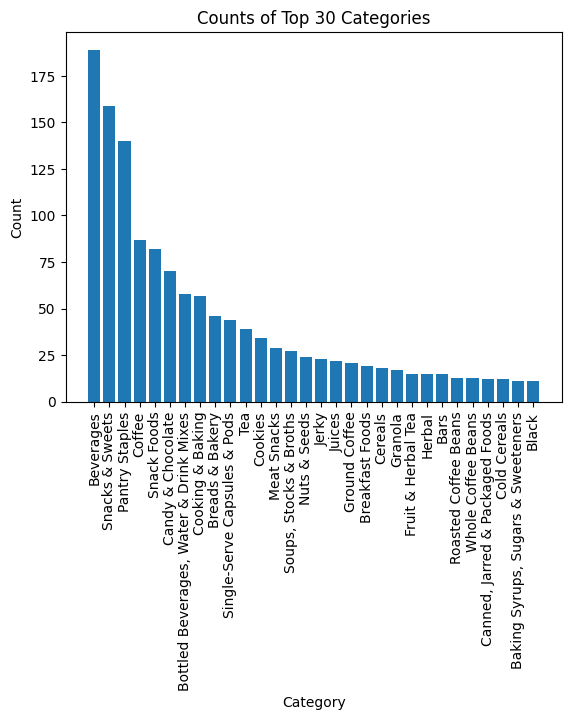

In [33]:
vc = categories.apply(pd.Series.value_counts)

plt.bar(x = vc.iloc[1].index, height = vc.iloc[1])
plt.xticks(rotation = 90)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Counts of Top 30 Categories')
plt.show()

In [34]:
amazon_data = amazon_data.drop(columns = 'categories')

In [35]:
amazon_data = amazon_data.join(categories)

In [36]:
amazon_data.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,product_review_count,user_review_count,...,Granola,Fruit & Herbal Tea,Herbal,Bars,Roasted Coffee Beans,Whole Coffee Beans,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,1,1,...,0,0,0,0,0,0,0,0,0,1
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,1,1,...,0,1,1,0,0,0,0,0,0,0
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,16.99,1,2,...,0,0,0,0,1,1,0,0,0,0
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,1,2,...,0,0,0,0,0,0,0,0,0,0
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,4,1,...,0,0,0,0,0,0,0,0,0,0


Now that I have added all of my features, I will look at distributions, correlations and skewness. I also only chose 30 of the top categories so the dataset wasn't filled with a lot of rarer categories. I also removed the grocery and gourment category since every product will contain this category since it is the category I chose for the reviews and meta data.

In [37]:
amazon_data.columns

Index(['rating', 'asin', 'parent_asin', 'user_id', 'helpful_vote',
       'verified_purchase', 'average_rating', 'price', 'product_review_count',
       'user_review_count', 'Beverages', 'Snacks & Sweets', 'Pantry Staples',
       'Coffee', 'Snack Foods', 'Candy & Chocolate',
       'Bottled Beverages, Water & Drink Mixes', 'Cooking & Baking',
       'Breads & Bakery', 'Single-Serve Capsules & Pods', 'Tea', 'Cookies',
       'Meat Snacks', 'Soups, Stocks & Broths', 'Nuts & Seeds', 'Jerky',
       'Juices', 'Ground Coffee', 'Breakfast Foods', 'Cereals', 'Granola',
       'Fruit & Herbal Tea', 'Herbal', 'Bars', 'Roasted Coffee Beans',
       'Whole Coffee Beans', 'Canned, Jarred & Packaged Foods', 'Cold Cereals',
       'Baking Syrups, Sugars & Sweeteners', 'Black'],
      dtype='str')

<Figure size 1200x1200 with 0 Axes>

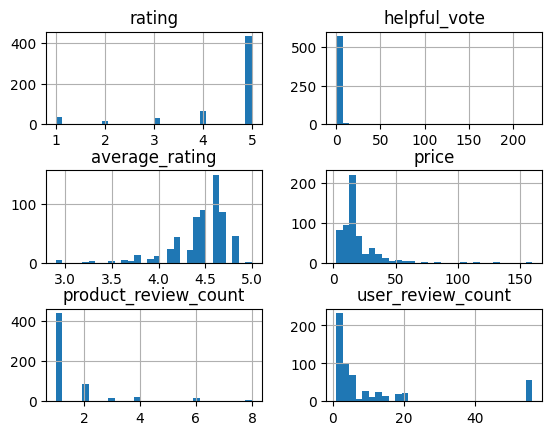

In [38]:
amazon_numerical = ['rating', 'helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count']

plt.figure(figsize = (12, 12))
amazon_data[amazon_numerical].hist(bins = 30)

plt.subplots_adjust(hspace = 0.5)
plt.show()

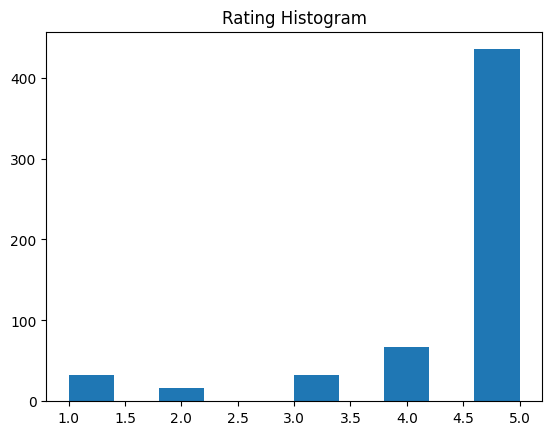

In [39]:
amazon_data['rating'].hist(grid = False)
plt.title('Rating Histogram')
plt.show()

Text(0.5, 1.0, 'User Review Count KDE Plot')

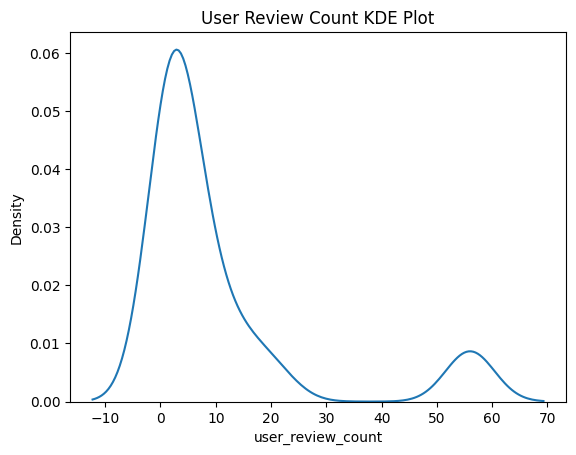

In [40]:
sns.kdeplot(amazon_data['user_review_count'])
plt.title('User Review Count KDE Plot')

Looking at the distributions, I will need to log transform the numerical values since they all are either heavily skewed to the left or the right. Furthermore, there is a large class imbalance with the rating column which will be what my model would predict. This could lead to some bias for the model and lead to it predicting 5 stars more often than the other ratings. I also wanted to look at the user review count distribution up closer due to the smaller peak at the end of the chart. I find it interesting that there is one small group of people that have written a lot more reviews than others. These could be scam reviews due to the large difference of reviews written between reviews.

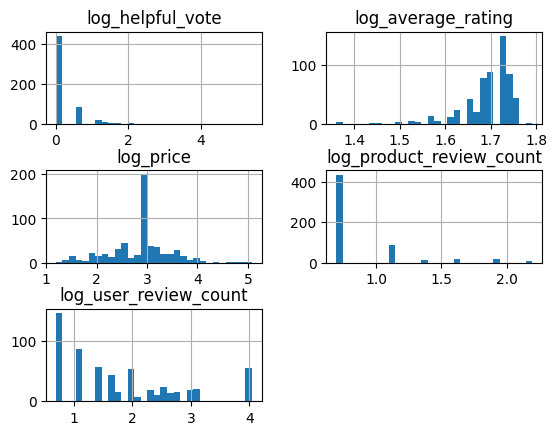

In [41]:
columns_to_transform = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count']

for col in columns_to_transform:
    amazon_data[f'log_{col}'] = np.log1p(amazon_data[col])

amazon_data[['log_helpful_vote', 'log_average_rating', 'log_price', 'log_product_review_count', 'log_user_review_count']].hist(bins = 30)

plt.subplots_adjust(hspace = 0.5)
plt.show()

In [42]:
amazon_data_transformed = amazon_data.drop(columns = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count'])

In [43]:
amazon_num = amazon_data_transformed.select_dtypes(include = 'number').columns

info = pd.DataFrame({'Mean' : amazon_data_transformed[amazon_num].mean(), 'Median' : amazon_data_transformed[amazon_num].median(), 'Mode' : amazon_data_transformed[amazon_num].mode().iloc[0]})

info

,Mean,Median,Mode
rating,4.466552,5.000000,5.000000
Beverages,0.324185,0.000000,0.000000
Snacks & Sweets,0.272727,0.000000,0.000000
Pantry Staples,0.240137,0.000000,0.000000
Coffee,0.149228,0.000000,0.000000
Snack Foods,0.140652,0.000000,0.000000
Candy & Chocolate,0.120069,0.000000,0.000000
"Bottled Beverages, Water & Drink Mixes",0.099485,0.000000,0.000000
Cooking & Baking,0.097770,0.000000,0.000000
Breads & Bakery,0.078902,0.000000,0.000000


In [44]:
plt.figure(figsize = (20, 20))

corr_mat = amazon_data_transformed[amazon_num].corr()

sorted_corr = corr_mat.unstack().sort_values(ascending= False)

sorted_corr[40:51]

Breakfast Foods  Cereals            0.972467
Cereals          Breakfast Foods    0.972467
Granola          Bars               0.937681
Bars             Granola            0.937681
Meat Snacks      Jerky              0.885780
Jerky            Meat Snacks        0.885780
Breads & Bakery  Cookies            0.850279
Cookies          Breads & Bakery    0.850279
Cereals          Cold Cereals       0.812195
Cold Cereals     Cereals            0.812195
                 Breakfast Foods    0.789833
dtype: float64

<Figure size 2000x2000 with 0 Axes>

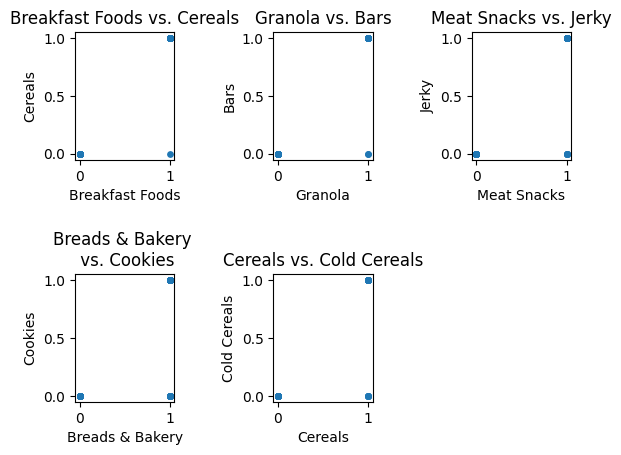

In [45]:
plt.subplot(2, 3, 1)
plt.scatter(amazon_data_transformed['Breakfast Foods'], amazon_data_transformed['Cereals'], s = 15)
plt.xlabel('Breakfast Foods')
plt.ylabel('Cereals')
plt.title('Breakfast Foods vs. Cereals')

plt.subplot(2, 3, 2)
plt.scatter(amazon_data_transformed['Granola'], amazon_data_transformed['Bars'], s = 15)
plt.xlabel('Granola')
plt.ylabel('Bars')
plt.title('Granola vs. Bars')

plt.subplot(2, 3, 3)
plt.scatter(amazon_data_transformed['Meat Snacks'], amazon_data_transformed['Jerky'], s = 15)
plt.xlabel('Meat Snacks')
plt.ylabel('Jerky')
plt.title('Meat Snacks vs. Jerky')

plt.subplot(2, 3, 4)
plt.scatter(amazon_data_transformed['Breads & Bakery'], amazon_data_transformed['Cookies'], s = 15)
plt.xlabel('Breads & Bakery')
plt.ylabel('Cookies')
plt.title('Breads & Bakery \n vs. Cookies')

plt.subplot(2, 3, 5)
plt.scatter(amazon_data_transformed['Cereals'], amazon_data_transformed['Cold Cereals'], s = 15)
plt.xlabel('Cereals')
plt.ylabel('Cold Cereals')
plt.title('Cereals vs. Cold Cereals')

plt.subplots_adjust(wspace = 1, hspace = 0.9)
plt.show()

<Axes: >

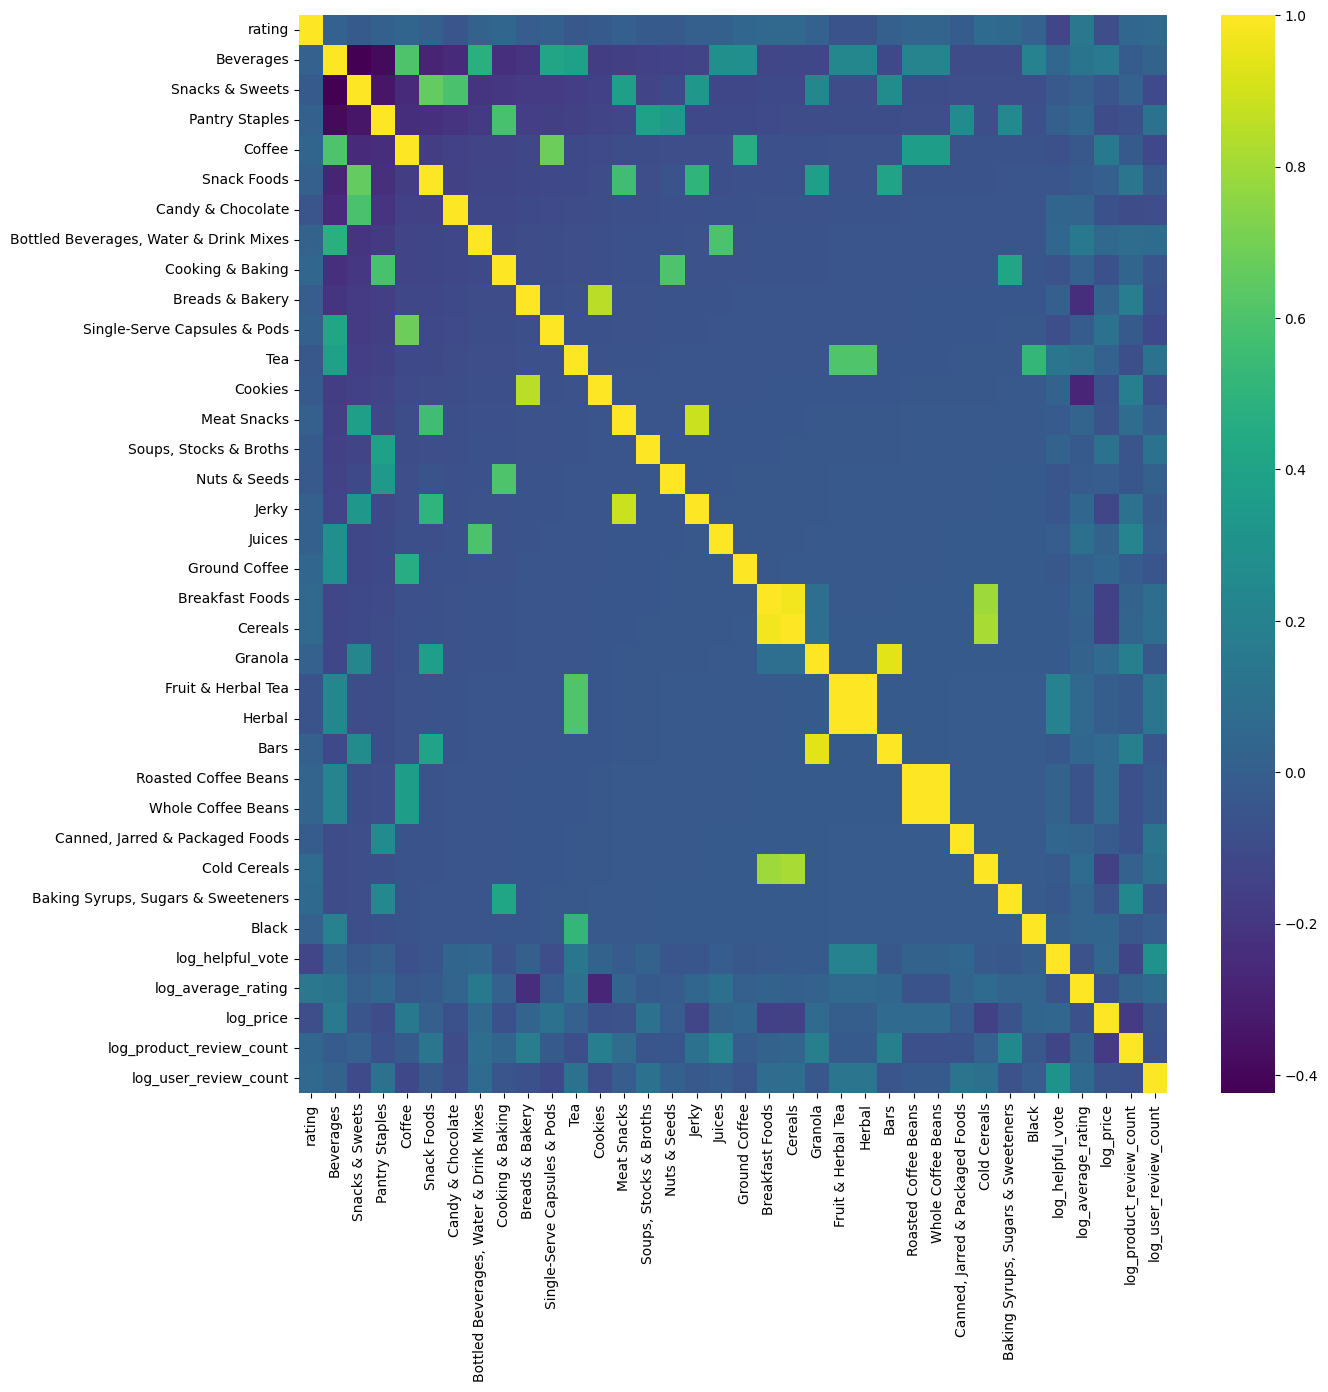

In [46]:
plt.figure(figsize = (14, 14))
sns.heatmap(corr_mat, cmap = 'viridis')

Looking at the correlation between the variables, I am not surprised at the top 10 correlations as they are all categories that can be together for an item. For example, if one of the items was Nature Grain Granola Bars, it would most likely be categorized as bars and granola since it can fit into both. Furthermore, I looked at the top 10 correlations that weren't 1 as a correlation means its the same value on the x and y axis or they are always categorized together. Breakfast Foods and Cereals have a correlation of 1 since they are always together when categorizing a cereal. I am curious what the difference between a cold cereal and a cereal is because they do have a higher correlation but they don't get categorized together all the time.

## Dataset 3: Ecommerce Data

In [47]:
ecom_data = pd.read_csv('/workspaces/DX699---HW-Assignments/data.csv', encoding = 'windows-1252')

ecom_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1/1/2020,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,1/1/2020,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,1/1/2020,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,1/1/2020,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,1/1/2020,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [48]:
ecom_data = ecom_data.drop(columns = ['Row ID', 'Product Name', 'Country', 'Postal Code', 'Order ID', 'Order Date'])

In [49]:
encoded_data = pd.get_dummies(ecom_data, columns = ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category'], dtype = int)

encoded_data.head()

,Customer ID,City,Product ID,Sales,Quantity,Discount,Profit,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,GA-14725,Lorain,FUR-FU-10003878,48.896,4,0.2,8.5568,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,SC-20725,Los Angeles,FUR-FU-10001215,474.430,11,0.0,199.2606,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,DP-13390,Franklin,OFF-BI-10002012,3.600,2,0.0,1.7280,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,JM-15250,Huntsville,OFF-ST-10002743,454.560,5,0.2,-107.9580,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,JM-15250,Huntsville,FUR-FU-10002116,141.420,5,0.6,-187.3815,0,0,0,...,0,0,1,0,0,0,0,0,0,0


<Axes: >

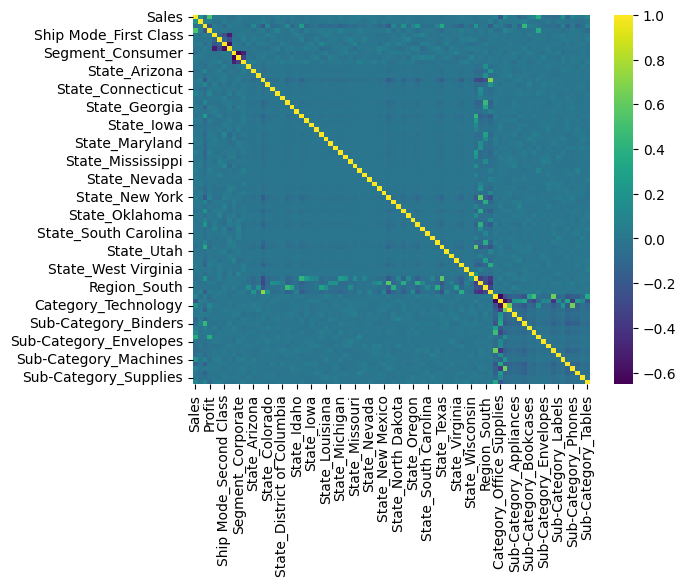

In [50]:
corr_mat_ecom = encoded_data.corr(numeric_only = True)

sns.heatmap(corr_mat_ecom, cmap = 'viridis')

In [51]:
sorted_mat = corr_mat_ecom.unstack().sort_values(ascending = False)

sorted_mat[82: 92]

Region_West               State_California            0.711855
State_California          Region_West                 0.711855
Sub-Category_Phones       Category_Technology         0.647793
Category_Technology       Sub-Category_Phones         0.647793
Sub-Category_Furnishings  Category_Furniture          0.635416
Category_Furniture        Sub-Category_Furnishings    0.635416
Sub-Category_Accessories  Category_Technology         0.624549
Category_Technology       Sub-Category_Accessories    0.624549
Region_Central            State_Texas                 0.587144
State_Texas               Region_Central              0.587144
dtype: float64

In [52]:
sorted_mat[6700 : 6725]

Region_Central            Region_East                -0.343896
Region_East               Region_Central             -0.343896
Category_Office Supplies  Sub-Category_Accessories   -0.371998
Sub-Category_Accessories  Category_Office Supplies   -0.371998
Category_Office Supplies  Sub-Category_Phones        -0.385843
Sub-Category_Phones       Category_Office Supplies   -0.385843
Region_West               Region_Central             -0.389413
Region_Central            Region_West                -0.389413
Sub-Category_Furnishings  Category_Office Supplies   -0.401485
Category_Office Supplies  Sub-Category_Furnishings   -0.401485
Region_East               Region_West                -0.436178
Region_West               Region_East                -0.436178
Segment_Consumer          Segment_Home Office        -0.504397
Segment_Home Office       Segment_Consumer           -0.504397
Ship Mode_First Class     Ship Mode_Standard Class   -0.529027
Ship Mode_Standard Class  Ship Mode_First Class      -0

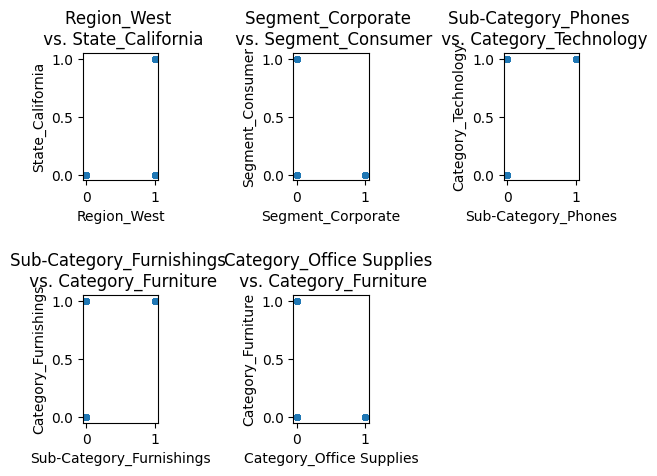

In [53]:
plt.subplot(2, 3, 1)
plt.scatter(encoded_data['Region_West'], encoded_data['State_California'], s = 15)
plt.xlabel('Region_West')
plt.ylabel('State_California')
plt.title('Region_West \n vs. State_California')

plt.subplot(2, 3, 2)
plt.scatter(encoded_data['Segment_Corporate'], encoded_data['Segment_Consumer'], s = 15)
plt.xlabel('Segment_Corporate')
plt.ylabel('Segment_Consumer')
plt.title('Segment_Corporate \n vs. Segment_Consumer')

plt.subplot(2, 3, 3)
plt.scatter(encoded_data['Sub-Category_Phones'], encoded_data['Category_Technology'], s = 15)
plt.xlabel('Sub-Category_Phones')
plt.ylabel('Category_Technology')
plt.title('Sub-Category_Phones \n vs. Category_Technology')

plt.subplot(2, 3, 4)
plt.scatter(encoded_data['Sub-Category_Furnishings'], encoded_data['Category_Furniture'], s = 15)
plt.xlabel('Sub-Category_Furnishings')
plt.ylabel('Category_Furnishings')
plt.title('Sub-Category_Furnishings \n vs. Category_Furniture')

plt.subplot(2, 3, 5)
plt.scatter(encoded_data['Category_Office Supplies'], encoded_data['Category_Furniture'], s = 15)
plt.xlabel('Category_Office Supplies')
plt.ylabel('Category_Furniture')
plt.title('Category_Office Supplies \n vs. Category_Furniture')

plt.subplots_adjust(wspace = 1.8, hspace = 0.9)
plt.show()

Looking at the correlations between the data, I am not surprised by the higher correlations. All of the features that share high correlations are all related in some way. For example, the region_west and state_california columns are related since california is in the western region. This means that when a purchase went through in California, it will always have region_west as a 1 as well. However, there are times where region west can be 1 and California can't since the order was placed in a different state.

## Conclusions about Data

After conducting my analyses on the data, I find that all datasets are usable! The first two datasets required a lot of preprocessing to make the data usable for a prediction model as a lot of the data was either separated or not in a usable form. I also had to create a lot of features in the instacart dataset for prediction including the target variable of reordered. Furthermore, the correlations that I found in each dataset weren't that surprising. For the instacart data, a lot of the correlations were between features that are very similar like last order and last product order. Furthermore, with the amazon dataset, the higher correlated features are categories that were in the nested lists together for different items. This also isn't surprising since the categories are very similar, like jerky and meat snacks.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

In [54]:
import random

n = 12
receive = random.sample(range(100, 401), n)
subs = random.sample(range(12, 30), n)
process = []

for i in range(len(subs)):
    process.append(receive[i] - subs[i])

data = {'Received' : receive, 'Processed' : process}

df = pd.DataFrame(data, index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

Text(12, 340, 'Received')

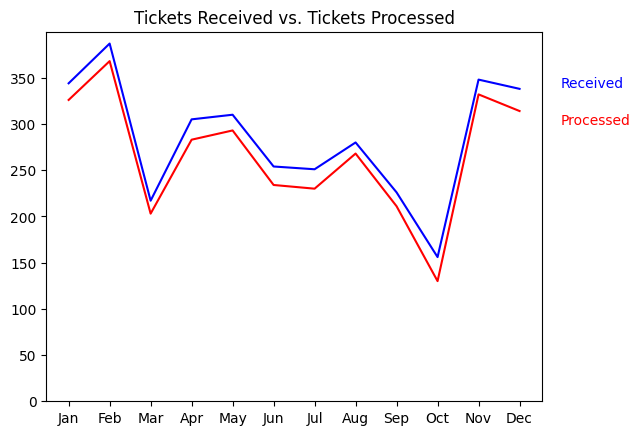

In [64]:
plt.plot(df['Received'], color = 'blue')
plt.plot(df['Processed'], color = 'red')
plt.ylim(0)
plt.title('Tickets Received vs. Tickets Processed')

plt.text(12, 300, 'Processed', c = 'Red')
plt.text(12, 340, 'Received', c = 'blue')